# Beyond TESS: Fitting ground-based follow-up of TESS targets

A single ground-based observation of one eclipse usually can't constrain a full eclipse model on
its own — there just aren't enough eclipses in one partial night to pin down the shape *and* the
timing simultaneously. 

`EBP_sweep` solves this by obtaining the precise eclipse *shape*
(depth, duration, impact parameter) from TESS data with the `batman`
method, and does a first fit of the pri or sec eclipse visits to pin down the 
eclipse shape in this filter. the result from this joint fit is used to fit 
individual visits to obtain their timing.

In [1]:
%load_ext autoreload
%autoreload 2

from EBP_sweep import config, read_global_eclipse_params, run_many,load

config.OUTPUT_DIR = 'tess_prior_run' #folder to store output results

## Run TESS fit using batman


This part only needs to be run once for all the interested targets and the result can be loaded in the next section

In [20]:
full_marvel_targets = [	'TIC 343127696',  
					'TIC 291751499', 
					'TIC_64366964', 
					'TIC_441496809', 
                    'TIC_198242678',
                    'TIC_165615442']
run_targets = []
for target in full_marvel_targets:
    try:
        _ = read_global_eclipse_params(target)
    except:
        run_targets.append(target)


run_targets
    

Reading global eclipse parameters from 'tess_prior_run/Figures/EclipseFit/TIC343127696/TIC343127696_GlobalParams.csv'
Reading global eclipse parameters from 'tess_prior_run/Figures/EclipseFit/TIC291751499/TIC291751499_GlobalParams.csv'


['TIC_64366964', 'TIC_441496809', 'TIC_198242678', 'TIC_165615442']

In [139]:
results = run_many(['TIC 115396972'],
					quality_bitmask="hardest", 
					methods=['batman'],
					verbose=False
					)

Data Download:Attempt 1 failed with error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Data Download:Attempt 2 failed with error: Request failed.  If this problem persists, please notify archive[at]stsci.edu.'
Data Download:Attempt 3 failed with error: Request failed.  If this problem persists, please notify archive[at]stsci.edu.'
Failed to download data for TIC ID TIC 115396972


## Load TESS eclipse parameters

choose target to analyse

In [58]:
tic_id = 'TIC 343127696'

pri_params, sec_params = read_global_eclipse_params(tic_id)

print(f"\n{'Parameter':12s}: {'Primary':25s} | {'Secondary':25s}")
print(f"{'-'*72}")
for k in pri_params:
 print(f"{k:12s}: {str(pri_params[k]):25s} | {str(sec_params[k]):25s}")

Reading global eclipse parameters from 'tess_prior_run/Figures/EclipseFit/TIC343127696/TIC343127696_GlobalParams.csv'

Parameter   : Primary                   | Secondary                
------------------------------------------------------------------------
t0          : 1742.6797+/-0.0004        | 1740.50848+/-0.00016     
P           : 4.6723066+/-0.0000013     | 4.672258548400649+/-0    
rp          : 0.5008+/-0.0019           | 0.4728+/-0.0023          
dur         : 0.6375+/-0.0021           | 0.6886+/-0.0031          
b           : 0.403+/-0.004             | 0.446+/-0.004            
u1          : 0.88+/-0.13               | 0.000+/-0.018            
u2          : -0.87+/-0.22              | 0.1+/-0.4                
Aev         : 0.01806+/-0.00018         | 0.01307+/-0.00021        
offset      : -0.01254+/-0.00026        | -0.01595+/-0.00028       
slope       : (5.7+/-1.7)e-07           | (3.1+/-1.8)e-07          


In [59]:
result = load(tic_id)
P = {}
P['pri'] = result.oc['P_primary_new']
P['sec'] = result.oc['P_secondary_new']

P['pri'], P['sec']

(4.672310991015741, 4.672264555108381)

## Load MARVEL data

In [60]:
import pandas as pd
marvel_folder = "../../../MARVEL_data"
target_folder = f"{marvel_folder}/TIC_{tic_id[4:]}"


observation_log = pd.read_csv(f"{marvel_folder}/MARVEL_CBPs.csv", index_col=0)
filt = observation_log.index == int(tic_id[4:])
obs = observation_log[filt]
obs

,Event,UTC Midpoint,La Palma Midpoint,Observing Night,JD,RA J2000,Dec J2000,RA deg,Dec deg,Alt mid deg,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
TIC,,,,,,,,,,,,,,,,,,,,,
343127696,Secondary,2026-07-14 00:09,2026-07-14 01:09 WEST,2026-07-13,2.461236e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,41.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Primary,2026-07-16 01:02,2026-07-16 02:02 WEST,2026-07-15,2.461238e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,49.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Secondary,2026-07-28 00:33,2026-07-28 01:33 WEST,2026-07-27,2.461250e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,51.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Primary,2026-07-30 01:25,2026-07-30 02:25 WEST,2026-07-29,2.461252e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,58.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Secondary,2026-08-11 00:57,2026-08-11 01:57 WEST,2026-08-10,2.461264e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,59.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Primary,2026-08-13 01:48,2026-08-13 02:48 WEST,2026-08-12,2.461266e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,62.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Secondary,2026-08-25 01:22,2026-08-25 02:22 WEST,2026-08-24,2.461278e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,62.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Primary,2026-08-27 02:11,2026-08-27 03:11 WEST,2026-08-26,2.461280e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,60.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343127696,Secondary,2026-09-08 01:46,2026-09-08 02:46 WEST,2026-09-07,2.461292e+06,22:18:06.2,+55:54:15.6,334.525833,55.904333,58.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re




star = SkyCoord(ra=obs["RA deg"].iloc[0]*u.deg, 
				dec=obs["Dec deg"].iloc[0]*u.deg, 
				frame='icrs')

observatory_location = EarthLocation.of_site('Roque de los Muchachos, La Palma')  

In [62]:

# list all observations of the target in the below format: a list of dictionaries, each containing
# the label (date), path to the light-curve file, eclipse type, and predicted time of eclipse.
# NIGHTS = [
# 	dict(label="2026-07-28", path=f"{target_folder}/TIC_343127696_V0743_Cep_webobs_20260728.txt",
# 		ecl_type="sec", T_pred=2461249.5),
# 		... 
# 		]

# Treat every raw webobs light-curve file sitting in the target folder as one observed night,
# and pull ecl_type / T_pred for each from the MARVEL prediction table loaded above (`obs`) -
obs_files = sorted(glob.glob(os.path.join(target_folder, "*.txt")))

utc_midpoint_date    = pd.to_datetime(obs["UTC Midpoint"]).dt.date
observing_night_date = pd.to_datetime(obs["Observing Night"]).dt.date

NIGHTS = []
for path in obs_files:
	fname = os.path.basename(path)
	date_match = re.search(r"(\d{8})\.txt$", fname)
	if date_match is None:
		raise ValueError(f"Could not find a YYYYMMDD date stamp in filename: {fname}")

	file_date = pd.to_datetime(date_match.group(1), format="%Y%m%d").date()
	label = file_date.strftime("%Y-%m-%d")

	# a file is named either for its UTC-midpoint calendar date, or for the observing night
	# it belongs to (when the eclipse falls after local midnight) - match on either
	row = obs[(utc_midpoint_date == file_date) | (observing_night_date == file_date)]
	if len(row) != 1:
		raise ValueError(f"Expected exactly one predicted eclipse in `obs` for {fname}, found {len(row)}")
	row = row.iloc[0]

	NIGHTS.append(dict(	label=label,
						path=path,
						ecl_type="pri" if row["Event"] == "Primary" else "sec",
						T_pred=row["JD"],
						)
					)

Display all visits with predicted mid-eclipse times

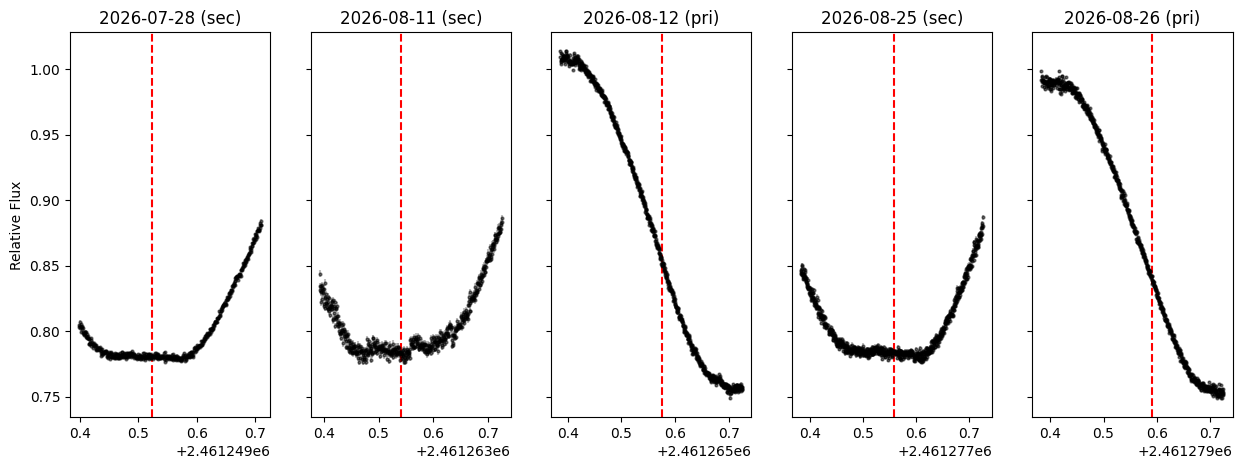

In [119]:
from EBP_sweep.io import mag_to_flux

# cycle through each night of observation
fig, axs = plt.subplots(1, len(NIGHTS), figsize=(15, 5), sharey=True)
axs[0].set_ylabel('Relative Flux')

for i,night in enumerate(NIGHTS):
	time, mag, mag_err = np.loadtxt( fname=night['path'], skiprows=7, delimiter=",",
									usecols=(1, 2, 3), unpack=True,  dtype=float)
	srt = np.argsort(time)
	time, mag, mag_err = time[srt], mag[srt], mag_err[srt]
	
	# Convert time form jd_utc to bjd_tdb
	t_ = Time(time, format='jd', scale='utc', location=observatory_location).tdb
	ltt = t_.light_travel_time(star, 'barycentric', ephemeris='builtin')
	time_bjd = (t_ + ltt).value

	#convert mag to flux
	flux, flux_err = mag_to_flux(mag, mag_err, nsim=1000)  # Convert magnitude and error to flux using Monte Carlo sampling
	night["abs_flux"] = flux
	night["abs_flux_err"] = flux_err
	flux, flux_err = flux / np.max(flux), flux_err / np.max(flux)   # Normalize flux and error to the maximum flux value

	# shift eclipse for bottom to be around depth observed in TESS light curve
	flux_bottom = 1 - sec_params["rp"].n**2 if night['ecl_type'] == 'sec' else 1 - pri_params["rp"].n**2
	flux = flux - flux.min() + flux_bottom 

	# Store the processed data back into the night dictionary
	night['time_bjd'] = time_bjd
	night['flux'] = flux
	night['flux_err'] = flux_err

	axs[i].errorbar(time_bjd, flux, yerr=flux_err, fmt='o', markersize=2, color='black', ecolor='gray', alpha=0.5)
	axs[i].axvline(night['T_pred'], color='red', linestyle='--')
	axs[i].set_title(f"{night['label']} ({night['ecl_type']})")


In [120]:
# import xml.etree.ElementTree as ET

# def read_xml_lightcurve(path):
#     """Parse a MARVEL webobs XML light-curve file.

#     Returns
#     -------
#     bjd_tdb, rel_flux, rel_flux_err : np.array
#     """
#     tree = ET.parse(path)
#     root = tree.getroot()

#     bjd_tdb = np.array([float(row.find('BJD_TDB').text) for row in root.findall('row')])
#     rel_flux = np.array([float(row.find('rel_flux').text) for row in root.findall('row')])
#     rel_flux_err = np.array([float(row.find('rel_flux_error').text) for row in root.findall('row')])

#     order = np.argsort(bjd_tdb)
#     return bjd_tdb[order], rel_flux[order], rel_flux_err[order]


# # quick test / plot
# bjd_tdb, rel_flux, rel_flux_err = read_xml_lightcurve(
#     "../../../MARVEL_data/TIC_441496809/TIC 441496809_20260912.xml"
# )
# flux_bottom = 1 - pri_params["rp"].n**2
# flux = rel_flux/rel_flux.max()
# flux = flux - flux.min() + flux_bottom 

# plt.errorbar(bjd_tdb, flux, yerr=rel_flux_err, fmt='o', markersize=2,
#              color='black', ecolor='gray', alpha=0.5)

# plt.errorbar(NIGHTS[-1]['time_bjd'], NIGHTS[-1]['flux'], yerr=NIGHTS[-1]['flux_err'], fmt='r', 
#             markersize=2, color='r', ecolor='gray', alpha=0.5)

# plt.xlabel('BJD_TDB')
# plt.ylabel('Relative Flux')

In [121]:
# #update Tpred if necessary based on above plot
# NIGHTS[0]["T_pred"] = 2461267.52
# NIGHTS[2]["T_pred"] = 2461285.72

## Joint fit of eclipse types to get best shape

different slope and offset are applied for each visit but the eclipse shape is consistent for all visits of same eclipse type

In [122]:
# Pool nights of the same eclipse type together: all primary-eclipse nights will share
# one eclipse shape (t0, P, rp, dur, b, u1, u2, Aev) in the upcoming joint batman fit,
# and likewise for all secondary-eclipse nights, while each individual night keeps its
# own baseline offset/slope via `pooled_visits` (see fit_global_eclipse_shape).
pooled = {}

for ecl_type in ('pri', 'sec'):
	type_nights = [night for night in NIGHTS if night['ecl_type'] == ecl_type]
	if not type_nights:
		continue

	pooled_time_bjd = np.concatenate([night['time_bjd'] for night in type_nights])
	pooled_flux     = np.concatenate([night['flux']     for night in type_nights])
	pooled_flux_err = np.concatenate([night['flux_err'] for night in type_nights])
	pooled_visits   = np.concatenate([np.full(night['time_bjd'].shape, night['label']) for night in type_nights])

	# keep the pooled arrays time-ordered
	order = np.argsort(pooled_time_bjd)

	pooled[ecl_type] = dict(
						time_bjd = pooled_time_bjd[order],
						flux     = pooled_flux[order],
						flux_err = pooled_flux_err[order],
						visits   = pooled_visits[order],
						visits_id = np.unique(pooled_visits[order], return_inverse=True)[1],
						nights   = [night['label'] for night in type_nights],
						)
	
	print(f"{ecl_type}: pooled {len(type_nights)} nights {pooled[ecl_type]['nights']} "
		  f"-> {len(pooled[ecl_type]['time_bjd'])} points total")

pri: pooled 2 nights ['2026-08-12', '2026-08-26'] -> 1784 points total
sec: pooled 3 nights ['2026-07-28', '2026-08-11', '2026-08-25'] -> 2041 points total


In [123]:
pooled.keys()

dict_keys(['pri', 'sec'])

In [124]:
from EBP_sweep.batman_fit import fit_global_eclipse_shape, batman_flux_model
from uncertainties import ufloat
import warnings
warnings.filterwarnings("ignore") 

fit_priors, fit_param, fit_model = {},{},{}

for ecl_type in pooled.keys():
	pars = pri_params if ecl_type == 'pri' else sec_params  # was keyed off the stale `night` var (fixed)
	T_pred0 = next(n['T_pred'] for n in NIGHTS if n['ecl_type'] == ecl_type)  # seed t0; periodicity locks in the rest

	fit_priors[ecl_type] = dict(	t0 		= (T_pred0-0.2, T_pred0, T_pred0+0.2),  #(min, start, max)
									offset 	= (-0.4,0.1,0.4),    #(min, start, max)
									slope	= (-0.1, 1e-2, 0.1),  					 
									# P 		= (pars['P'].n,1),					 #gaussian
									P 		= P[ecl_type],					 #fixed
									rp 		= (pars['rp'].n, 3*pars['rp'].s),    # (mu, sigma) 5 x unc
									dur 	= (pars['dur'].n, 1*pars['dur'].s),  # 1 x unc
									# dur 	= pars['dur'].n,  # 1 x unc

									Aev 	= pars['Aev'].n,
									b 		= pars['b'].n,
									u1 		= (pars['u1'].n, pars['u1'].s, 0, 2),
									u2 		= (pars['u2'].n, pars['u2'].s, -1, 1),
									)
	
	fit_param[ecl_type], fit_model[ecl_type] = fit_global_eclipse_shape(pooled[ecl_type]['time_bjd'], 
																		pooled[ecl_type]['flux'], 
																		pooled[ecl_type]['flux_err'],
																		param_priors=fit_priors[ecl_type], 
																		pooled_visits=pooled[ecl_type]['visits'], 
																		return_model=True)

# fit_param['pri'], fit_param['sec']

	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.


In [125]:
fit_param['sec']

name,value,standard error,relative error,initial value,min,max,vary
t0,2461249.51,0.00127053,(0.00%),2461249.5241,2461249.32,2461249.72,True
P,4.67226456,0.00000000,(0.00%),4.672264555108381,-inf,inf,False
rp,0.47846180,0.00756263,(1.58%),0.4727848715255078,-inf,inf,True
dur,0.69959651,0.01216715,(1.74%),0.6886058465574143,-inf,inf,True
b,0.44617098,0.00000000,(0.00%),0.4461709800150269,-inf,inf,False
u1,0.00140921,0.15497910,(10997.60%),1.1077438633044778e-08,0.00000000,2.00000000,True
u2,-0.05395449,0.21381633,(396.29%),0.0772691912573941,-1.00000000,1.00000000,True
Aev,0.01307036,0.00000000,(0.00%),0.01307036252396,-inf,inf,False
offset_0,0.02175741,0.00533817,(24.53%),0.1,-0.40000000,0.40000000,True
offset_1,0.02665067,0.00538150,(20.19%),0.1,-0.40000000,0.40000000,True


In [126]:
#SPLIT PARAMETERS PER VISIT
visit_params = {}
for ecl_type in pooled.keys():
	visit_params[ecl_type] = [fit_param[ecl_type].copy() for _ in range(len(pooled[ecl_type]['nights']))]

	for i in range(len(pooled[ecl_type]['nights'])):
		for j in range(len(pooled[ecl_type]['nights'])):
			if j==i:
				visit_params[ecl_type][i]['offset'] = fit_param[ecl_type][f'offset_{j}']
				visit_params[ecl_type][i]['slope'] = fit_param[ecl_type][f'slope_{j}']
				del visit_params[ecl_type][i][f'offset_{j}']
				del visit_params[ecl_type][i][f'slope_{j}']
			else:
				del visit_params[ecl_type][i][f'offset_{j}']
				del visit_params[ecl_type][i][f'slope_{j}']
	

overplot joint fit for each visit

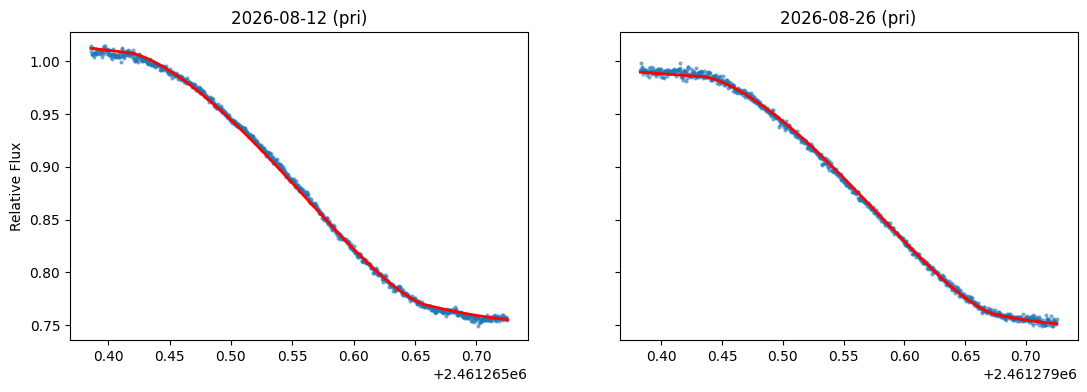

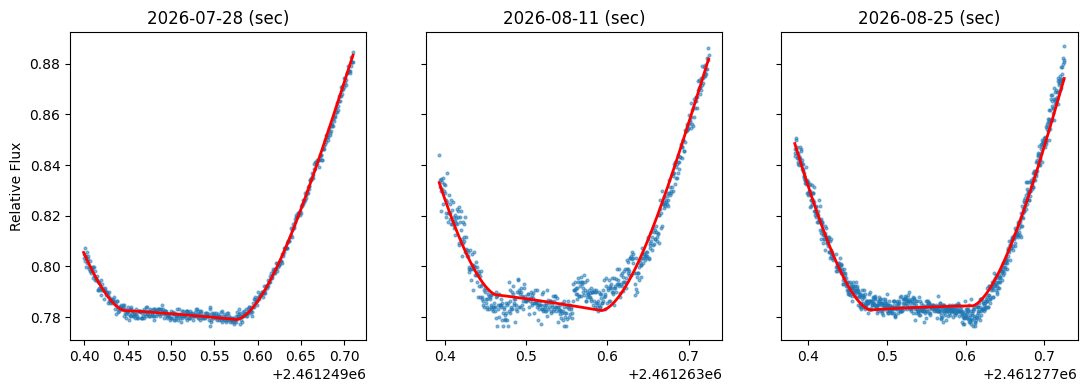

In [127]:
for ecl_type in pooled.keys():
	type_nights = [night for night in NIGHTS if night['ecl_type'] == ecl_type]
	fig, axs = plt.subplots(1, len(type_nights), figsize=(13, 4), sharey=True)
	axs = np.atleast_2d(axs).flatten()

	axs[0].set_ylabel('Relative Flux')

	for i, night in enumerate(type_nights):
		# Store the processed data back into the night dictionary
		smooth_time = np.linspace(night["time_bjd"].min(), night["time_bjd"].max(), 1000)
		smooth_flux = batman_flux_model(fit_model, visit_params[ecl_type][i], t=smooth_time)
		axs[i].plot(night["time_bjd"], night['flux'], 'o', markersize=2, alpha=0.5)
		axs[i].plot(smooth_time, smooth_flux, color='red', lw=2)
		axs[i].set_title(f"{night['label']} ({night['ecl_type']})")


show  phase folded visits to see how they align

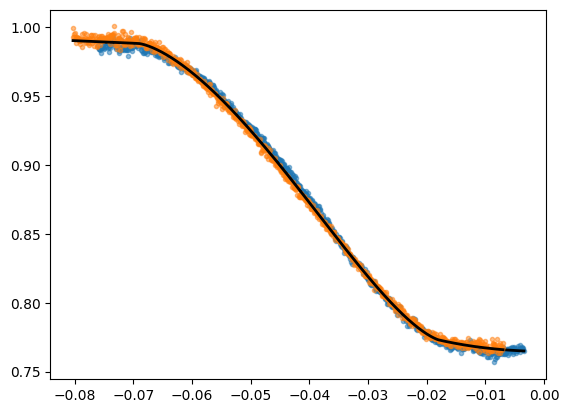

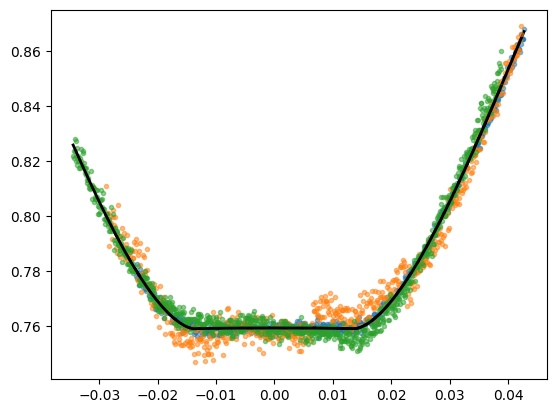

In [128]:
from EBP_sweep.utils import phase_fold

for ecl_type in pooled.keys():
	fig = plt.figure()
	type_nights = [night for night in NIGHTS if night['ecl_type'] == ecl_type]

	for i,night in enumerate(type_nights):
		if night['ecl_type'] == ecl_type:
			night["phases"] = phase_fold(night['time_bjd'], fit_param[ecl_type]['P'].value, fit_param[ecl_type]['t0'].value,-0.25)
			best_ecl, trend = batman_flux_model(fit_model[ecl_type], visit_params[ecl_type][i], 
											   t=night["time_bjd"], return_trend=True)
			plt.plot(night["phases"], night['flux']-trend, '.', alpha=0.5)
			plt.plot(night["phases"], best_ecl-trend, color='k', lw=2)
			# plt.plot(night["phases"], trend, color='blue', lw=2)


## Fit for visit T0s

	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.
	GLOBAL FIT: Fit succeeded.


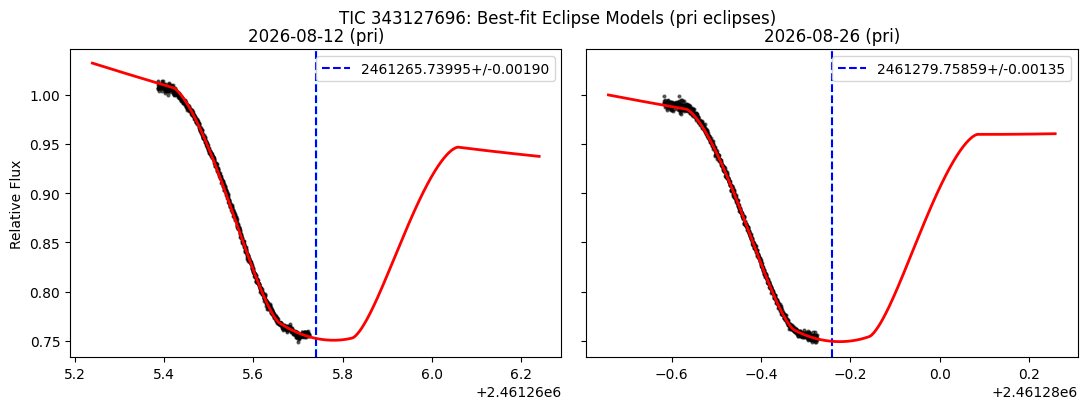

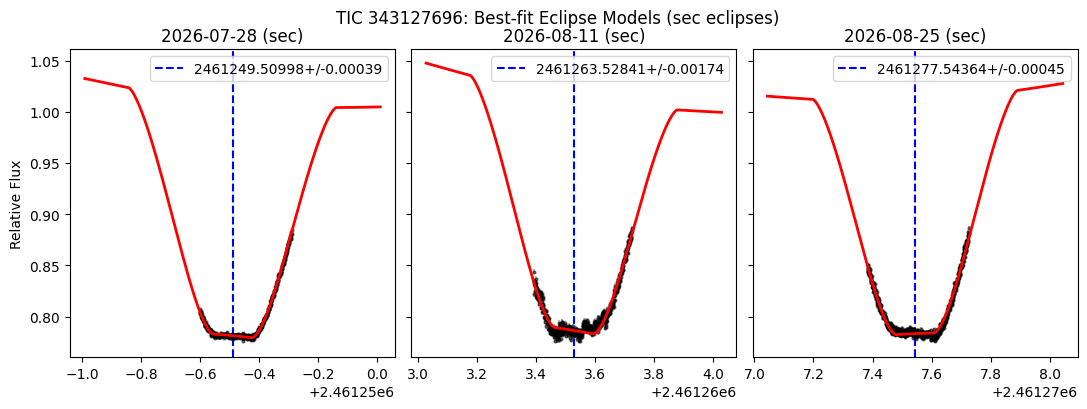

In [129]:
from EBP_sweep.batman_fit import fit_global_eclipse_shape, batman_flux_model
from uncertainties import ufloat
import warnings
warnings.filterwarnings("ignore")

fit_params = {}   # ecl_type -> best-fit lmfit.Parameters (shared shape + one offset_i/slope_i per night)
fit_models = {}   # ecl_type -> batman.TransitModel used for the fit

for ecl_type in ["pri","sec"]:

	fit_params[ecl_type] = []
	fit_models[ecl_type] = []
	### fit all nights of this eclipse type jointly: one shared eclipse shape, but each
	### night keeps its own offset/slope via `pooled_visits`
	type_nights = [night for night in NIGHTS if night['ecl_type'] == ecl_type]
	fig, axs = plt.subplots(1, len(type_nights), figsize=(13, 4), sharey=True)
	axs = np.atleast_1d(axs)
	axs[0].set_ylabel('Relative Flux')

	for i, night in enumerate(type_nights):

		pars = visit_params[ecl_type][i]
		T_pred0 = night['T_pred']
		fit_priors = dict(	t0 		= (T_pred0-0.2, T_pred0, T_pred0+0.2),  #(min, start, max)
							offset 	= pars["offset"].value, # 0.01*pars["offset"].stderr),    #(min, start, max), fit independently per night
							slope	= pars["slope"].value,# 0.01*pars["slope"].stderr),  					 
							P 		= P[ecl_type],						 #fixed
							rp 		= (pars['rp'].value, 1*pars['rp'].stderr),    # (mu, sigma) 5 x unc
							dur 	= (pars['dur'].value, 1*pars['dur'].stderr),  # 1 x unc
							Aev 	= pars['Aev'].value,
							b 		= pars['b'].value,
							u1 		= pars['u1'].value,
							u2 		= pars['u2'].value,
							)

		fit_param, fit_model = fit_global_eclipse_shape(night['time_bjd'], night['flux'], night['flux_err'],
														param_priors=fit_priors,
														return_model=True)
		fit_params[ecl_type].append(fit_param)
		fit_models[ecl_type].append(fit_model)


		axs[i].errorbar(night["time_bjd"], night['flux'], yerr=night['flux_err'], fmt='o', markersize=2, 
						color='black', ecolor='gray', alpha=0.5)
		smooth_time = np.linspace(fit_param['t0'].value - 0.5, fit_param['t0'].value + 0.5, 1000)
		smooth_flux = batman_flux_model(fit_model, fit_param, t=smooth_time)
		axs[i].plot(smooth_time, smooth_flux, color='red', lw=2, zorder=5)
		axs[i].axvline(fit_param['t0'].value, color='blue', linestyle='--', label=f'{ufloat(fit_param["t0"].value, fit_param["t0"].stderr):.5f}')
		axs[i].axvspan(fit_param['t0'].value - fit_param['t0'].stderr, 
						fit_param['t0'].value + fit_param['t0'].stderr, color='cyan', alpha=0.1)
		axs[i].set_title(f"{night['label']} ({night['ecl_type']})")
		axs[i].legend()

	plt.suptitle(f"TIC {tic_id[4:]}: Best-fit Eclipse Models ({ecl_type} eclipses)")
	plt.subplots_adjust(wspace=0.05)



In [130]:
for ecl_type in ['pri','sec']:
	print("Primary" if ecl_type == 'pri' else "\nSecondary")
	for i in range(len(visit_params[ecl_type])):
		print(fit_params[ecl_type][i]['t0'])
	


Primary
<Parameter 't0', value=2461265.7399485214 +/- 0.0019, bounds=[2461265.3760699998:2461265.77607]>
<Parameter 't0', value=2461279.7585899155 +/- 0.00135, bounds=[2461279.3920699996:2461279.79207]>

Secondary
<Parameter 't0', value=2461249.509982961 +/- 0.00039, bounds=[2461249.3241:2461249.7241]>
<Parameter 't0', value=2461263.5284069274 +/- 0.00174, bounds=[2461263.3409599997:2461263.74096]>
<Parameter 't0', value=2461277.543637117 +/- 0.000447, bounds=[2461277.3578299996:2461277.75783]>


## write eclipse times to OC_txtfile for that target


In [131]:
import os
oc_dir = config.data_path(config.OC_TXT_DIR)
oc_file = os.path.join(oc_dir, f'TIC{tic_id[4:]}_OCwErr_new.txt')
oc_file

'tess_prior_run/Data/OC_txtfiles/TIC343127696_OCwErr_new.txt'

In [132]:
import pandas as pd
# OC timing file
df = pd.read_csv(oc_file, header=0, skiprows=[1], usecols=[0,1,3])
df.columns = df.columns.str.strip().str.lstrip('#').str.strip() 
df['instr'] = ['T'] * len(df)


# add new eclipse times to df
new_rows = []
for ecl_type, flag in (("pri", 0), ("sec", 1)):
    for fp in fit_params.get(ecl_type, []):
        new_rows.append({
            'eclipse_time': fp["t0"].value - 2457000,
            'eclipse_time_err': fp["t0"].stderr,
            'flag': flag,
            'instr': 'M',
        })

new_times = pd.DataFrame(new_rows, columns=df.columns)

df = pd.concat([df, new_times], ignore_index=True)
P_avg = (P['pri'] + P['sec']) / 2
df['epoch'] = ((df['eclipse_time'] - df['eclipse_time'].iloc[0]) / P_avg).round(2)
#round off epoch using: np.ceil if pri but np.floor if sec
df.loc[df['flag'] == 0, 'epoch_int'] = np.ceil(df.loc[df['flag'] == 0, 'epoch']).astype(int)
df.loc[df['flag'] == 1, 'epoch_int'] = np.floor(df.loc[df['flag'] == 1, 'epoch']).astype(int)
df

,eclipse_time,eclipse_time_err,flag,instr,epoch,epoch_int
0,1742.677194,0.000538,0,T,0.00,0.0
1,1752.023123,0.000628,0,T,2.00,2.0
2,1756.696167,0.000343,0,T,3.00,3.0
3,1770.711724,0.000418,0,T,6.00,6.0
4,1775.383492,0.000581,0,T,7.00,7.0
...,...,...,...,...,...,...
60,4265.739949,0.001902,0,M,540.01,541.0
61,4279.758590,0.001350,0,M,543.01,544.0
62,4249.509983,0.000390,1,M,536.53,536.0
63,4263.528407,0.001736,1,M,539.53,539.0


In [133]:
#save the updated eclipse times to a CSV file
times_dir = config.data_path("TESS_plus_ground_times")
os.makedirs(times_dir, exist_ok=True)
df.to_csv(os.path.join(times_dir, f'TIC{tic_id[4:]}_alltimes.csv'), index=False)


In [134]:
times = {"pri": df.loc[df['flag'] == 0],
         "sec": df.loc[df['flag'] == 1]}

best_P = {"pri": None, "sec": None}
best_t0 = {"pri": None, "sec": None}
best_lin_model = {"pri": None, "sec": None}
resid = {"pri": None, "sec": None}

for ecl_type  in ['pri', 'sec']:
        coeff,cov = np.polyfit(times[ecl_type]['epoch_int'], times[ecl_type]['eclipse_time'], 1, w=1/times[ecl_type]['eclipse_time_err'], cov=True)
        best_P[ecl_type] = ufloat(coeff[0], np.sqrt(cov[0,0]))
        best_t0[ecl_type] = ufloat(coeff[1], np.sqrt(cov[1,1]))
        # best_lin_model[ecl_type] = np.polyval(coeff, times[ecl_type]['epoch_int'])

best_P_avg = (best_P['pri'].n + best_P['sec'].n) / 2
for ecl_type  in ['pri', 'sec']:
    best_lin_model[ecl_type] = best_t0[ecl_type].n + best_P_avg * times[ecl_type]['epoch_int']
    resid[ecl_type] = times[ecl_type]['eclipse_time'] - best_lin_model[ecl_type]


In [135]:
best_P

{'pri': 4.672009021489739+/-0.0004097092212015021,
 'sec': 4.672263245672747+/-1.912860209179154e-06}

In [136]:
%matplotlib inline

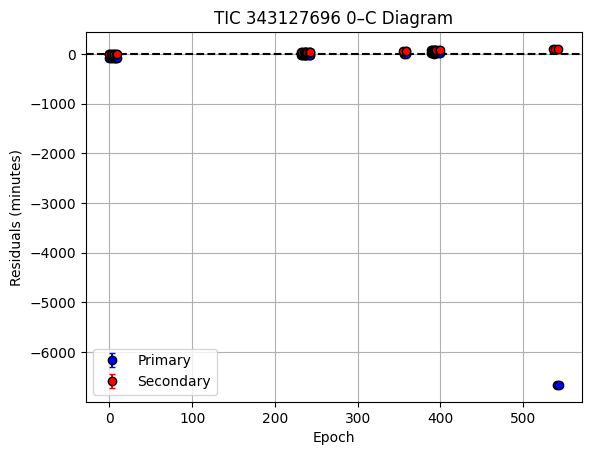

In [137]:
plt.errorbar(times['pri']['epoch_int'], resid['pri']*24*60, yerr=times['pri']['eclipse_time_err']*24*60, mec='k', fmt='bo', capsize=2,label='Primary')
plt.errorbar(times['sec']['epoch_int'], resid['sec']*24*60, yerr=times['sec']['eclipse_time_err']*24*60, mec='k', fmt='ro', capsize=2,label='Secondary')
plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Residuals (minutes)')
plt.title(f'{tic_id} 0–C Diagram')
# plt.ylim(-200, 10)
plt.savefig(os.path.join(times_dir, f'TIC{tic_id[4:]}_alltimes.png'), bbox_inches='tight')